In [14]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from typing import Optional, Type, Union
from scipy.interpolate import CubicSpline
import time

#few imports
from few.trajectory.inspiral import EMRIInspiral #function to generate trajectories
from few.trajectory.ode.base import ODEBase #superclass for defining modified flux trajectories
from few.trajectory.ode.flux import KerrEccEqFlux #Adiabatic KerrEccEq base trajectory class

from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum
from few.utils.modeselector import ModeSelector
from few.utils.exceptions import TrajectoryOffGridException

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)

##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux, KerrEccEqFlux #trajectory module. KerrEccEqFlux used to generate p_at_plunge
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################

from few.waveform.base import SphericalHarmonicWaveformBase #generic waveform generation class
from few.utils.baseclasses import SphericalHarmonic, KerrEccentricEquatorial, ParallelModuleBase, BackendLike

from few.utils.constants import YRSID_SI

from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )

use_gpu = False #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself.

In [16]:
# define parameters
m1 = 1e6
m2 = 1e4
a = 0.9
e0 = 0.01 #must be >> 0.0, but << 1.0 :)
Y0 = 1.0
dist = 1.0
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/5.
phiK = np.pi/6.
Phi_phi0 = 0.1
Phi_theta0 = 0.2
Phi_r0 = 0.3
dt = 10.0
T = 1.0
chi2 = 0.6

#initializing trajectories
start = time.time()
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
print(time.time() - start)

adiabatic_traj = EMRIInspiral(func=KerrEccEqFlux)

#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
p0 = get_p_at_t(traj_module=adiabatic_traj, t_out=T, traj_args=[m1, m2, a, e0, Y0]) + 0.1 #near plunge EMRI
print('p0: ', p0)

5.637435436248779
p0:  41.754136307294324


In [17]:
#sparse trajectories prone to spline errors, denser trajectories give a more accurate picture of dephasings.

max_step_days = 10.0 #max trajectory step size in days. Smaller value leads to more stable trajectories, but takes longer to compute. Likely needs fiddling.
max_step_size = max_step_days*24*60*60 #in seconds
inspiral_kwargs = {
    "err":1e-11, #error tolerance in the DOPR integration routine. Default = 1e-11
    "max_step_size":max_step_size, #in seconds
}

0.25664281845092773
0.29183006286621094
0.21663355827331543


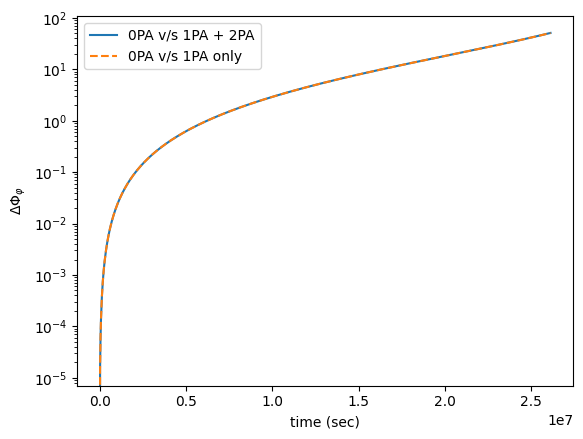

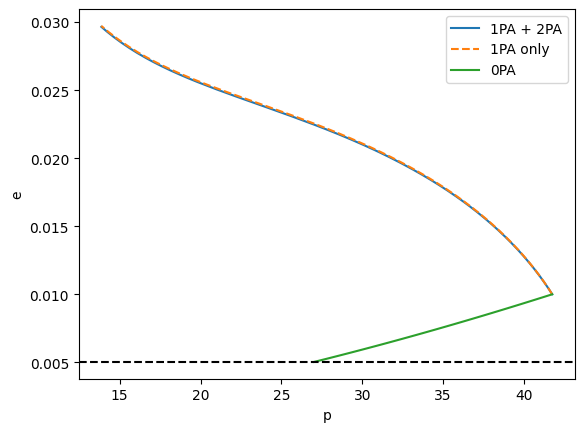

In [18]:
#Kerr Adiabatic (0PA) v/s SuperKludge (1PA + 2PA) v/s SuperKludge (1PA)

#1PA + 2PA
start = time.time()
evolve_1PA = True
evolve_primary = False
evolve_2PA = True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]
t1, p1, e1, x1, pp1, pt1, pr1, _, _ = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt, max_step_size=max_step_size)
print(time.time() - start)

#1PA only
start = time.time()
evolve_1PA = True
evolve_primary = False
evolve_2PA = False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]
t2, p2, e2, x2, pp2, pt2, pr2, _, _ = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt, max_step_size=max_step_size)
print(time.time() - start)

#0PA
start = time.time()
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]
t3, p3, e3, x3, pp3, pt3, pr3, _, _ = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt, max_step_size=max_step_size)
print(time.time() - start)

min_t1_t2 = min(t2[-1],t1[-1])
max_t1_t2 = max(t2[0],t1[0])

t = np.linspace(max(t3[0],max_t1_t2),min(t3[-1],min_t1_t2),1000)
pp1 = CubicSpline(t1,pp1)(t)
pp2 = CubicSpline(t2,pp2)(t)
pp3 = CubicSpline(t3,pp3)(t)

plt.plot(t,np.abs(pp3-pp1),label='0PA v/s 1PA + 2PA')
plt.plot(t,np.abs(pp3-pp2),linestyle='--',label='0PA v/s 1PA only')
plt.xlabel('time (sec)')
plt.ylabel(r'$\Delta\Phi_{\varphi}$')
plt.yscale('log')
plt.legend()
plt.savefig(f'phase_diff_SK_vs_KerrEccFlux_m1_{m1}_m2_{m2}.png',transparent=False)
plt.show()

plt.plot(p1,e1,label='1PA + 2PA')
plt.plot(p2,e2,linestyle='--',label='1PA only')
plt.plot(p3,e3,label='0PA')
plt.axhline(0.005,linestyle='--',color='k')
plt.xlabel('p')
plt.ylabel('e')
plt.legend()
plt.savefig(f'p_vs_e_m1_{m1}_m2_{m2}.png',transparent=False)
plt.show()

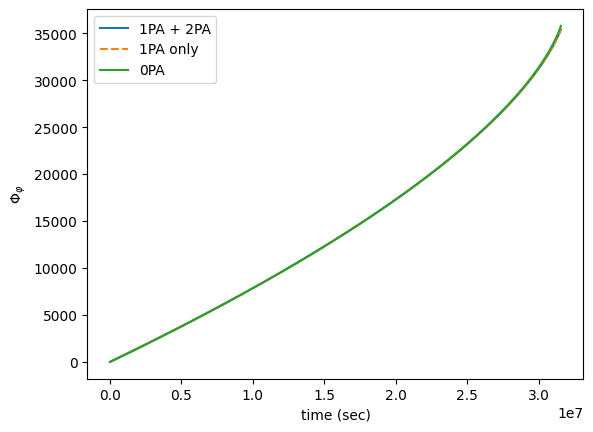

In [11]:
plt.plot(t,pp1,label='1PA + 2PA')
plt.plot(t,pp2,linestyle='--',label='1PA only')
plt.plot(t,pp3,label='0PA')
plt.xlabel('time (sec)')
plt.ylabel(r'$\Phi_{\varphi}$')
#plt.yscale('log')
plt.legend()
plt.savefig(f'abs_phase_SK_vs_KerrEccFlux_m1_{m1}_m2_{m2}.png',transparent=False)
plt.show()

0.21120381355285645
0.22608399391174316


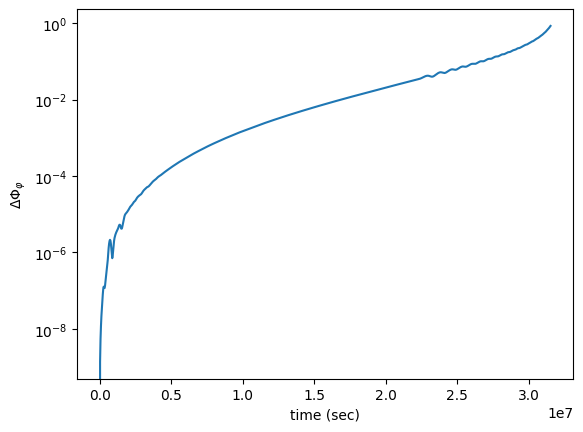

In [12]:
#SuperKludge (1PA) v/s SuperKludge (1PA + 2PA) - no primary evolution

#1PA
start = time.time()
evolve_1PA = True
evolve_primary = False
evolve_2PA = False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]
t1, p1, e1, x1, pp1, pt1, pr1, _, _ = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt, max_step_size=max_step_size)
print(time.time() - start)

#1PA + 2PA
start = time.time()
evolve_1PA = True
evolve_primary = False
evolve_2PA = True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]
t2, p2, e2, x2, pp2, pt2, pr2, _, _ = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt, max_step_size=max_step_size)
print(time.time() - start)

t = np.linspace(max(t1[0],t2[0]),min(t2[-2],t1[-2]),1000)
pp1 = CubicSpline(t1,pp1)(t)
pp2 = CubicSpline(t2,pp2)(t)

plt.plot(t,np.abs(pp2-pp1))
plt.xlabel('time (sec)')
plt.ylabel(r'$\Delta\Phi_{\varphi}$')
plt.yscale('log')
plt.savefig(f'phase_diff_SK_1PA_vs_2PA_m1_{m1}_m2_{m2}.png',transparent=False)
plt.show()

In [13]:
#waveform setup

sum_kwargs=dict(pad_output=False, odd_len=True)

start = time.time()
wave = GenerateEMRIWaveform(SuperKludgeWaveform,sum_kwargs=sum_kwargs, return_list=True)
print(time.time()-start)

76.80279183387756


In [11]:
evolve_1PA = True
evolve_primary = False
evolve_2PA = True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]

start = time.time()
for _ in range(10):
    waveform = wave(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
print('average time: ', (time.time()-start)/10)

average time:  4.43214602470398


In [12]:
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]

wave_null = wave(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)

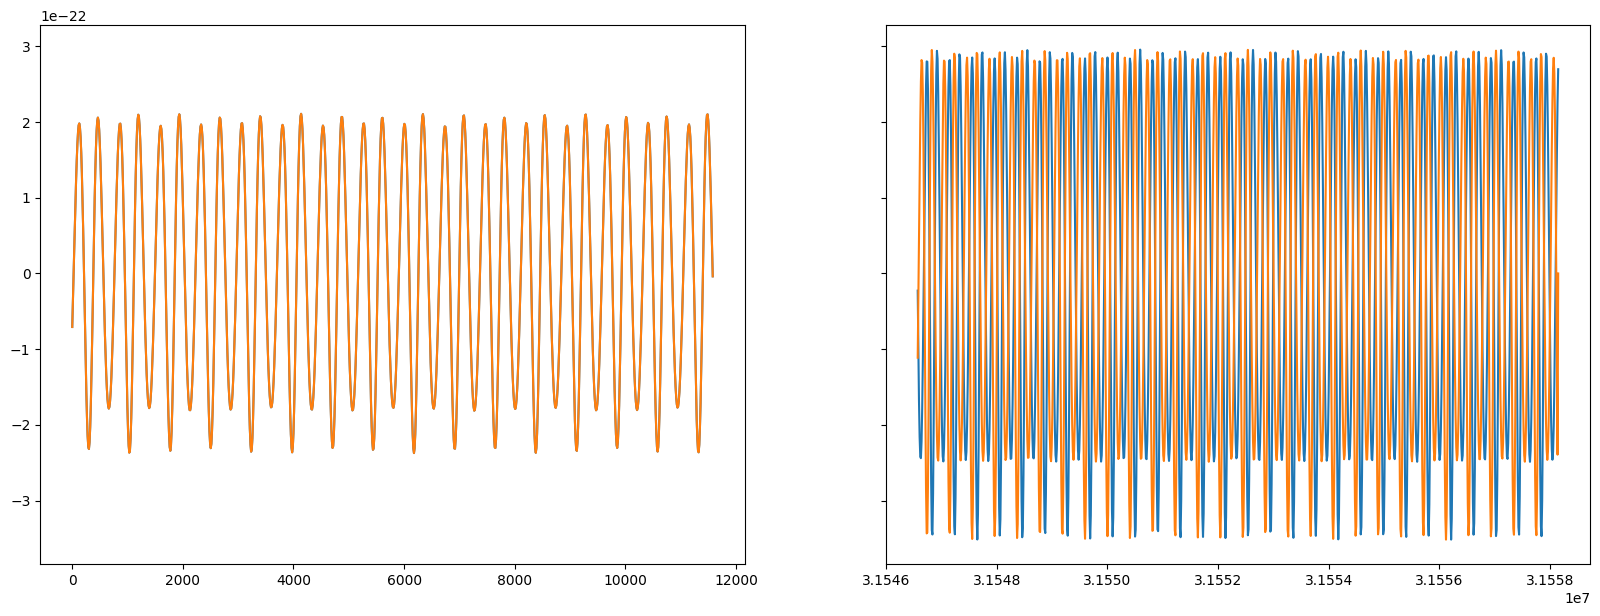

In [13]:
time_steps = np.linspace(0.0,T*YRSID_SI,len(cp.asnumpy(cp.asarray(waveform))[0]))

fig, axs = plt.subplots(1,2,figsize=(20,7),sharey=True)

if use_gpu:
    waveform = waveform.get()
    wave_null = wave_null.get()
    
axs[0].plot(time_steps[:1000],waveform[0][:1000])
axs[0].plot(time_steps[:1000],wave_null[0][:1000])

axs[1].plot(time_steps[-1000:],waveform[0][-1000:])
axs[1].plot(time_steps[-1000:],wave_null[0][-1000:])

plt.savefig(f'wave_snaps_m1_{m1}_m2_{m2}.png',transparent=False)
plt.show()